# Chapter 3 — Statistical Experiments and Significance Testing

## Practical Statistics for Data Scientists

This chapter discusses statistical experiments and methods for determining whether an observed difference is likely to represent a real effect or simply random variation.

The main topics include A/B testing, hypothesis testing, permutation tests, statistical significance, p-values, t-tests, ANOVA, chi-square tests, multi-arm bandit algorithms, and power and sample size.

---

## 3.1 A/B Testing

### Theoretical Explanation

An **A/B test** is an experiment that compares two groups in order to determine whether one treatment performs differently from another.

Usually, one group receives the existing or standard treatment, while another group receives a new treatment. The existing treatment is often referred to as the **control**.

A properly designed A/B test uses random assignment so that subjects are assigned to the treatment groups randomly. Randomization helps ensure that differences between the groups are caused either by the treatment itself or by random variation.

### Important Terms

**Treatment**  
Something that is applied or shown to a subject, such as a product price, web page design, advertisement, or medical treatment.

**Treatment Group**  
A group of subjects that receives a particular treatment.

**Control Group**  
A group that receives the standard treatment or no treatment.

**Randomization**  
The process of randomly assigning subjects to different treatment groups.

**Subjects**  
The individuals or objects exposed to the treatments, such as customers, website visitors, patients, or experimental units.

**Test Statistic**  
A metric used to measure and compare the effect of treatments.

---

### Example of an A/B Test

The book presents an ecommerce pricing experiment with the following results:

| Outcome | Price A | Price B |
|---|---:|---:|
| Conversion | 200 | 182 |
| No Conversion | 23,539 | 22,406 |

In this experiment, the researcher wants to determine whether different prices influence the probability that a visitor makes a purchase.

The response variable is binary because a visitor either:

- converts, or
- does not convert.

A/B testing is therefore useful for evaluating whether an observed difference between two treatments is meaningful or could simply result from random variation.

## 3.1.1 Why Have a Control Group?

A control group is important because it provides a baseline for comparison.

If a treatment is applied without a control group, a change in the outcome cannot confidently be attributed to the treatment because other external factors may also have changed.

When both the treatment and control groups experience approximately the same conditions, except for the treatment being tested, differences between the groups can be interpreted more reliably.

In data science, this principle is especially important in online experiments. For example, website visitors can be randomly assigned to two versions of a web page. Their responses, such as clicks, purchases, or time spent on the page, can then be compared.

An important principle is that the **test statistic should be determined before analyzing the experimental results**. Choosing a metric only after seeing the data can introduce researcher bias.

## 3.1.2 Why Just A/B? Why Not C, D, ...?

Experiments are not limited to only two treatments.

A/B testing is popular because comparing two alternatives is simple and practical, particularly in marketing and web experiments. However, experiments may include three or more treatments.

For example, a company could simultaneously compare:

- Price A
- Price B
- Price C
- Price D

Traditional experimental designs can be used for multiple treatments, but the decision-making process becomes more complex.

In data science applications, the objective is often not only to determine whether treatments are statistically different, but also to determine which treatment performs best.

This idea leads to another method discussed later in this chapter: the **Multi-Arm Bandit Algorithm**.

## 3.2 Hypothesis Tests

### Theoretical Explanation

A **hypothesis test**, also called a significance test, is a statistical procedure used to evaluate whether an observed effect could reasonably be explained by random chance.

In an A/B experiment, an observed difference between groups can occur because:

1. there is a real difference between the treatments, or
2. random variation caused the observed difference.

Hypothesis testing helps determine whether random chance is a reasonable explanation for the observed result.

The main concepts in hypothesis testing are:

- **Null Hypothesis**
- **Alternative Hypothesis**
- **One-Way Test**
- **Two-Way Test**

### 3.2.1 The Null Hypothesis

The **null hypothesis**, usually written as **H₀**, represents the assumption that nothing unusual or meaningful has happened.

In an A/B experiment, the null hypothesis generally assumes that the treatments are equivalent and that any observed difference between the groups is caused by random chance.

For example:

**H₀: There is no difference between the mean outcomes of Group A and Group B.**

The hypothesis test initially assumes that the null hypothesis is true.

A probability model representing this assumption is called the **null model**.

The observed result is then compared with what could reasonably occur under this null model.

If the observed difference is much more extreme than what random chance would normally produce, there is evidence against the null hypothesis.

### 3.2.2 Alternative Hypothesis

The **alternative hypothesis**, usually written as **H₁** or **Hₐ**, represents the explanation that competes with the null hypothesis.

It describes the effect or difference that we are interested in detecting.

Examples include:

**Example 1**

H₀: There is no difference between Group A and Group B.

H₁: Group A is different from Group B.

**Example 2**

H₀: A ≤ B

H₁: A > B

**Example 3**

H₀: Treatment B is not substantially better than Treatment A.

H₁: Treatment B is substantially better than Treatment A.

The null and alternative hypotheses together should cover the possible outcomes of the experiment.

The structure of the hypothesis test depends on how these hypotheses are defined.

### 3.2.3 One-Way Versus Two-Way Hypothesis Tests

Hypothesis tests can be either **one-way (one-tailed)** or **two-way (two-tailed)**.

#### One-Way Test

A one-way test evaluates an effect in only one specified direction.

For example, suppose Treatment B is a new treatment and Treatment A is the existing treatment.

The hypotheses could be:

**H₀: B ≤ A**

**H₁: B > A**

The test is only interested in determining whether B performs better than A.

Extreme results in the opposite direction are not counted when evaluating the alternative hypothesis.

---

#### Two-Way Test

A two-way test evaluates whether the groups differ in either direction.

The hypotheses could be:

**H₀: A = B**

**H₁: A ≠ B**

In this case, both possibilities are considered:

- A performs better than B, or
- B performs better than A.

Therefore, extreme results in either direction contribute to the statistical test.

---

### One-Way vs Two-Way Summary

| Test | Alternative Hypothesis | Direction |
|---|---|---|
| One-Way / One-Tailed | A > B or A < B | One direction |
| Two-Way / Two-Tailed | A ≠ B | Both directions |

In many A/B testing situations, a one-way test may be appropriate when a new treatment must demonstrate that it is better than an existing default treatment.

However, statistical software commonly reports two-tailed tests by default.

### Key Takeaways

- Hypothesis testing evaluates whether an observed effect could reasonably occur because of random variation.
- The **null hypothesis (H₀)** assumes that there is no meaningful difference and that observed differences are due to chance.
- The **alternative hypothesis (H₁)** represents the competing explanation that a real difference or effect exists.
- A **one-way test** evaluates an effect in one specified direction.
- A **two-way test** evaluates differences in both directions.
- The hypothesis test starts by assuming that the null hypothesis is true and evaluates whether the observed result is reasonable under that assumption.

## 3.3 Resampling

### Theoretical Explanation

**Resampling** is a statistical technique in which observations from an existing dataset are repeatedly sampled in order to evaluate the variability of a statistic.

Two important resampling methods are:

- **Bootstrap**, which is mainly used to evaluate the reliability or uncertainty of an estimate.
- **Permutation Test**, which is mainly used for hypothesis testing and comparisons between two or more groups.

In a permutation test, observations from different groups are combined and randomly redistributed into new groups.

This process represents the null hypothesis that the original treatment groups are equivalent and that any observed difference could have occurred because of random variation.

### 3.3.1 Permutation Test

The general procedure of a permutation test is:

1. Combine observations from the different groups into one dataset.
2. Shuffle the combined observations.
3. Randomly divide the observations into groups with the same sizes as the original groups.
4. Calculate the statistic of interest, such as the difference between group means.
5. Record the result.
6. Repeat the process many times to construct a permutation distribution.

The observed statistic is then compared with this permutation distribution.

If the observed difference is common in the permutation distribution, the difference may reasonably be explained by random chance.

If the observed difference is unusually extreme compared with the permutation distribution, this provides evidence that the difference may not be caused by random chance.

## 3.3.2 Example: Web Stickiness

A company wants to compare two different web page presentations, Page A and Page B.

Because actual sales occur infrequently and require a long sales cycle, the company uses **session time** as a proxy variable.

The assumption is that a web page that keeps visitors engaged for a longer period may potentially perform better.

The dataset contains:

- 21 sessions for Page A
- 15 sessions for Page B
- 36 sessions in total

The objective is to determine whether the difference in average session time between Page A and Page B could simply be the result of random variation.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
# Load the Web Page Data dataset from the official book repository

url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/web_page_data.csv"

session_times = pd.read_csv(url)

# Convert time values to seconds
session_times['Time'] = 100 * session_times['Time']

session_times.head()

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0


In [4]:
session_times.groupby('Page').size()

,0
Page,
Page A,21
Page B,15


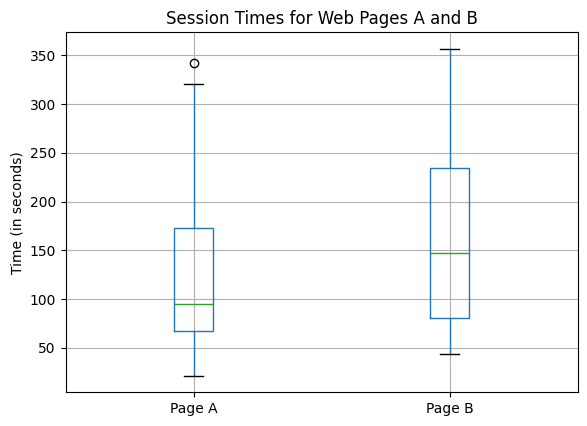

In [5]:
ax = session_times.boxplot(by='Page', column='Time')

ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')

plt.suptitle('')
plt.title('Session Times for Web Pages A and B')
plt.show()

In [6]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()

print(f"Mean Page A: {mean_a:.2f} seconds")
print(f"Mean Page B: {mean_b:.2f} seconds")
print(f"Difference (B - A): {mean_b - mean_a:.2f} seconds")

Mean Page A: 126.33 seconds
Mean Page B: 162.00 seconds
Difference (B - A): 35.67 seconds


### Interpretation

The average session time for Page A is approximately **126.33 seconds**, while the average session time for Page B is approximately **162.00 seconds**.

Therefore, visitors spend approximately **35.67 seconds longer on Page B** on average.

However, this difference alone does not prove that Page B is genuinely better.

The next step is to perform a **permutation test** to determine whether a difference of this magnitude could reasonably occur because of random variation.

### 3.3.3 Permutation Test for Web Stickiness

To determine whether the observed difference of approximately 35.67 seconds could occur by random chance, a permutation test is performed.

The session times from Page A and Page B are treated as if they came from the same underlying population under the null hypothesis.

The values are then randomly reassigned into:

- 21 observations for Page A
- 15 observations for Page B

For each permutation, the difference between the two group means is calculated.

This process is repeated 1,000 times to create a permutation distribution of possible differences under the null hypothesis.

In [8]:
# Define permutation function

def perm_fun(x, nA, nB):
    n = nA + nB

    # Randomly select indices for group B
    idx_B = set(random.sample(range(n), nB))

    # Remaining indices become group A
    idx_A = set(range(n)) - idx_B

    # Convert sets to lists for compatibility with Google Colab / modern pandas
    idx_A = list(idx_A)
    idx_B = list(idx_B)

    return x.iloc[idx_B].mean() - x.iloc[idx_A].mean()

In [9]:
nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]

print("Number of observations in Page A:", nA)
print("Number of observations in Page B:", nB)

Number of observations in Page A: 21
Number of observations in Page B: 15


In [10]:
# Perform 1,000 permutation tests

random.seed(1)

perm_diffs = [
    perm_fun(session_times['Time'].reset_index(drop=True), nA, nB)
    for _ in range(1000)
]

perm_diffs = np.array(perm_diffs)

print("Number of permutations:", len(perm_diffs))
print("First 10 permutation differences:")
print(perm_diffs[:10])

Number of permutations: 1000
First 10 permutation differences:
[  6.52380952 -17.59047619  22.86666667  -6.16190476  10.2952381
  -9.01904762   5.83809524 -49.01904762  -7.64761905 -14.73333333]


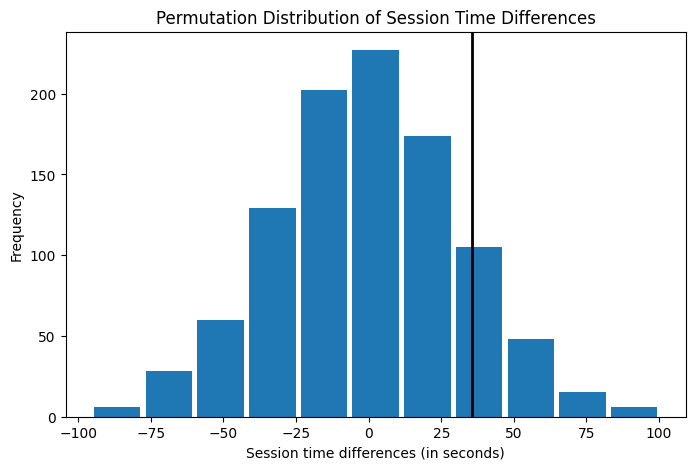

In [11]:
# Plot permutation distribution

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(perm_diffs, bins=11, rwidth=0.9)

ax.axvline(
    x=mean_b - mean_a,
    color='black',
    linewidth=2
)

ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Permutation Distribution of Session Time Differences')

plt.show()

In [12]:
# Calculate permutation p-value

observed_difference = mean_b - mean_a

p_value = np.mean(perm_diffs > observed_difference)

print(f"Observed difference: {observed_difference:.2f} seconds")
print(f"Permutation p-value: {p_value:.3f}")

Observed difference: 35.67 seconds
Permutation p-value: 0.121


### Interpretation of the Permutation Test

The observed difference in average session time between Page B and Page A is approximately **35.67 seconds**.

After randomly reallocating the observations between the two groups 1,000 times, approximately **12%** of the permutation results produced a difference greater than the observed difference.

This means that a difference as large as the observed result is not particularly unusual under random variation.

Therefore, the observed difference between Page A and Page B is still within the range of what could reasonably occur by chance.

At the conventional 5% significance level, the result is **not statistically significant**.

Although Page B has a higher average session time, the permutation test does not provide strong enough evidence to conclude that the difference represents a genuine treatment effect.

### 3.3.4 Exhaustive and Bootstrap Permutation Tests

There are two additional forms of permutation testing.

**Exhaustive Permutation Test**

An exhaustive permutation test calculates every possible way the observations can be divided between the groups.

Because the number of possible combinations can become extremely large, this method is generally practical only for relatively small datasets.

It is also sometimes called an **exact test**.

**Bootstrap Permutation Test**

In a bootstrap permutation test, observations are sampled **with replacement**, unlike a standard permutation test where observations are reassigned without replacement.

This approach incorporates both:

- randomness in treatment assignment, and
- randomness associated with sampling subjects from a population.

### Key Takeaways

- A permutation test evaluates whether an observed difference could reasonably occur because of random variation.
- The observations from all groups are combined and randomly reassigned.
- The statistic of interest is recalculated many times.
- The resulting permutation distribution represents differences expected under the null hypothesis.
- The observed difference is compared with this distribution.
- In the Web Stickiness example, the observed difference of about 35.67 seconds is not statistically significant.
- Permutation tests are flexible because they can be applied to different types of data without requiring a normal distribution assumption.

## 3.4 Statistical Significance and p-Values

### Theoretical Explanation

**Statistical significance** refers to whether an observed experimental result is more extreme than what could reasonably be produced by random chance.

If an observed result lies outside the range normally produced by random variation under the null hypothesis, the result is considered statistically significant.

Important concepts include:

- **p-value**: the probability, under a chance model representing the null hypothesis, of obtaining a result as unusual or more extreme than the observed result.
- **Alpha (α)**: a threshold chosen in advance for determining statistical significance.
- **Type I Error**: concluding that an effect is real when it is actually caused by chance.
- **Type II Error**: concluding that an effect is not real when a real effect actually exists.

A small p-value provides evidence that the observed result would be unusual under the null hypothesis.

### 3.4.1 Ecommerce Price Experiment

The book considers an ecommerce experiment comparing two prices.

| Outcome | Price A | Price B |
|---|---:|---:|
| Conversion | 200 | 182 |
| No Conversion | 23,539 | 22,406 |

The total number of observations is:

- Price A: 23,739
- Price B: 22,588

The conversion rates are approximately:

- Price A: 0.8425%
- Price B: 0.8057%

Therefore, the observed difference in conversion rates is approximately **0.0368 percentage points**.

The objective is to determine whether this observed difference could reasonably occur because of random variation under the null hypothesis that both prices have the same conversion rate.

In [13]:
# Calculate the observed difference in conversion rates

conversion_A = 200
total_A = 23739

conversion_B = 182
total_B = 22588

rate_A = 100 * conversion_A / total_A
rate_B = 100 * conversion_B / total_B

obs_pct_diff = rate_A - rate_B

print(f"Conversion rate Price A: {rate_A:.4f}%")
print(f"Conversion rate Price B: {rate_B:.4f}%")
print(f"Observed difference: {obs_pct_diff:.4f}%")

Conversion rate Price A: 0.8425%
Conversion rate Price B: 0.8057%
Observed difference: 0.0368%


In [16]:
# Create pooled conversion data under the null hypothesis

conversion = [0] * 45945
conversion.extend([1] * 382)

conversion = pd.Series(conversion)

print("Total observations:", len(conversion))
print("Total conversions:", conversion.sum())
print("Total non-conversions:", len(conversion) - conversion.sum())

Total observations: 46327
Total conversions: 382
Total non-conversions: 45945


In [17]:
# Perform 1,000 permutation tests

random.seed(1)

perm_diffs_conversion = [
    100 * perm_fun(conversion, 23739, 22588)
    for _ in range(1000)
]

perm_diffs_conversion = np.array(perm_diffs_conversion)

print("Number of permutations:", len(perm_diffs_conversion))
print("First 10 permutation differences:")
print(perm_diffs_conversion[:10])

Number of permutations: 1000
First 10 permutation differences:
[-0.06267673 -0.0194787   0.02371934  0.17923226 -0.02811831 -0.22682926
 -0.06267673 -0.04539752 -0.12315398  0.02371934]


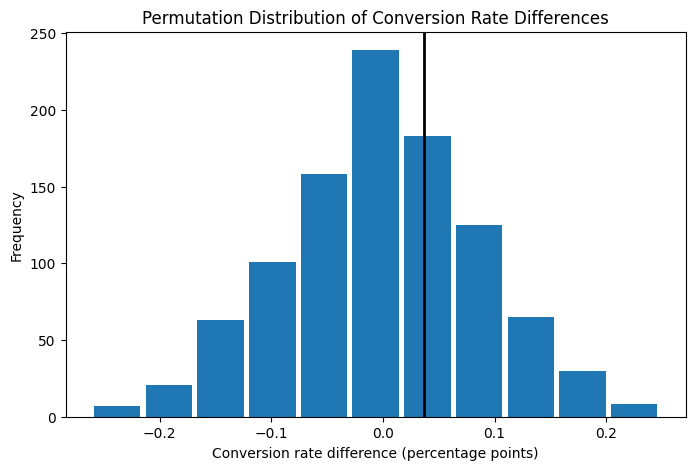

In [18]:
# Visualize the permutation distribution

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    perm_diffs_conversion,
    bins=11,
    rwidth=0.9
)

ax.axvline(
    x=obs_pct_diff,
    color='black',
    linewidth=2
)

ax.set_xlabel('Conversion rate difference (percentage points)')
ax.set_ylabel('Frequency')
ax.set_title('Permutation Distribution of Conversion Rate Differences')

plt.show()

### 3.4.2 p-Value

A **p-value** measures how frequently a chance model produces a result that is as extreme as, or more extreme than, the observed result.

In this experiment, the null hypothesis assumes that Price A and Price B have the same underlying conversion rate.

The p-value can therefore be estimated from the permutation test by calculating the proportion of permutation differences that are greater than or equal to the observed difference.

In [19]:
# Estimate the p-value from the permutation test

p_value_perm = np.mean(
    perm_diffs_conversion >= obs_pct_diff
)

print(f"Permutation p-value: {p_value_perm:.3f}")

Permutation p-value: 0.332


### Interpretation

The permutation p-value is approximately **0.30**.

This means that under the null hypothesis, a difference at least as large as the observed conversion-rate difference can occur relatively frequently because of random variation.

Since the p-value is much greater than the commonly used significance level of 0.05, the observed difference is **not statistically significant**.

Therefore, the experiment does not provide sufficient evidence to reject the null hypothesis that Price A and Price B have the same underlying conversion rate.

This does not prove that the two prices are identical. Rather, the observed data do not provide strong enough evidence to establish a difference.

In [20]:
from scipy import stats

In [21]:
# Create the 2x2 contingency table

survivors = np.array([
    [200, 23739 - 200],
    [182, 22588 - 182]
])

survivors

array([[  200, 23539],
       [  182, 22406]])

In [22]:
# Chi-square approximation

chi2, p_value, df, expected = stats.chi2_contingency(survivors)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {df}")
print(f"Single-sided p-value: {p_value / 2:.4f}")

Chi-square statistic: 0.1489
Degrees of freedom: 1
Single-sided p-value: 0.3498


### 3.4.3 Alpha

**Alpha (α)** is a significance threshold that is specified before evaluating the results of a statistical test.

Common values include:

- α = 0.05
- α = 0.01

A common decision framework is:

- If **p-value < α**, the observed result is considered statistically significant.
- If **p-value ≥ α**, there is insufficient evidence to reject the null hypothesis.

For the ecommerce example:

p-value ≈ 0.30

α = 0.05

Since:

p-value > α

the result is not statistically significant.

However, a p-value should not be interpreted as the probability that the null hypothesis is true or as the probability that the result occurred purely by chance.

### 3.4.4 Type I and Type II Errors

Statistical hypothesis testing can produce two important types of errors.

#### Type I Error

A **Type I Error** occurs when we conclude that an effect is real even though the apparent effect is actually caused by random chance.

In other words:

**Reject H₀ when H₀ should not have been rejected.**

---

#### Type II Error

A **Type II Error** occurs when we fail to identify a real effect and instead attribute the observed result to random variation.

In other words:

**Fail to reject H₀ even though a real effect exists.**

A nonsignificant result should therefore not automatically be interpreted as proof that no effect exists.

The sample may simply be too small to detect the effect.

### Key Takeaways

- Statistical significance evaluates whether an observed result is unusually extreme under a chance model.
- The **p-value** measures how frequently results as extreme as the observed result could occur under the null hypothesis.
- **Alpha** is a significance threshold selected before the statistical test.
- A large p-value does not prove that the null hypothesis is true.
- Statistical significance does not necessarily imply practical importance.
- A **Type I Error** occurs when a random effect is incorrectly treated as real.
- A **Type II Error** occurs when a real effect is not detected.
- In the Price A versus Price B experiment, the observed conversion-rate difference is not statistically significant.

## 3.5 t-Tests

### Theoretical Explanation

A **t-test** is a statistical significance test used to evaluate whether an observed difference between groups could reasonably occur because of random variation.

The t-test is based on **Student's t-distribution**, originally developed to approximate the distribution of a sample mean.

Important terms include:

**Test Statistic**  
A numerical measure of the difference or effect being investigated.

**t-Statistic**  
A standardized version of the test statistic that expresses the observed difference relative to its variability.

**t-Distribution**  
A reference probability distribution used to evaluate the observed t-statistic under the null hypothesis.

Before modern computers made large-scale resampling practical, statistical tests such as the t-test provided a convenient analytical approximation to permutation-based significance testing.

In [23]:
# Separate session times for Page A and Page B

page_a = session_times[
    session_times.Page == 'Page A'
].Time

page_b = session_times[
    session_times.Page == 'Page B'
].Time

print("Page A observations:", len(page_a))
print("Page B observations:", len(page_b))

print(f"Mean Page A: {page_a.mean():.2f}")
print(f"Mean Page B: {page_b.mean():.2f}")

Page A observations: 21
Page B observations: 15
Mean Page A: 126.33
Mean Page B: 162.00


### Hypotheses

For the Web Stickiness example:

**H₀:** The mean session time for Page A is equal to or greater than the mean session time for Page B.

**H₁:** The mean session time for Page A is lower than the mean session time for Page B.

Therefore, this is a **one-sided test**.

In [24]:
equal_var=False

In [25]:
# Welch Two-Sample t-Test

res = stats.ttest_ind(
    page_a,
    page_b,
    equal_var=False
)

print(f"t-statistic: {res.statistic:.4f}")
print(f"Two-sided p-value: {res.pvalue:.4f}")
print(f"One-sided p-value: {res.pvalue / 2:.4f}")

t-statistic: -1.0983
Two-sided p-value: 0.2815
One-sided p-value: 0.1408


In [26]:
# Modern SciPy syntax for a one-sided Welch t-test

res_one_sided = stats.ttest_ind(
    page_a,
    page_b,
    equal_var=False,
    alternative='less'
)

print(f"t-statistic: {res_one_sided.statistic:.4f}")
print(f"One-sided p-value: {res_one_sided.pvalue:.4f}")

t-statistic: -1.0983
One-sided p-value: 0.1408


### Interpretation

The Welch two-sample t-test produces a t-statistic of approximately **-1.10** and a one-sided p-value of approximately **0.1408**.

The negative t-statistic reflects that the mean session time for Page A is lower than the mean for Page B.

However:

p-value = 0.1408

which is greater than the conventional significance level:

α = 0.05

Therefore, the result is **not statistically significant** at the 5% significance level.

There is not sufficient statistical evidence to conclude that Page B produces a genuinely longer average session time than Page A.

This conclusion is consistent with the earlier permutation test.

### Permutation Test vs t-Test

The permutation test and t-test approach the same question in different ways.

| Method | Main Approach |
|---|---|
| Permutation Test | Builds a null distribution directly by repeatedly shuffling the observed data |
| t-Test | Standardizes the observed difference and compares it with the theoretical t-distribution |

For the Web Stickiness example:

- Permutation p-value ≈ 0.12
- t-test p-value ≈ 0.14

Both methods indicate that the observed difference is not statistically significant.

Permutation tests are intuitive and flexible because the null distribution is generated from the observed data.

The t-test instead relies on a standard reference distribution and provides a convenient analytical approximation.

### Key Takeaways

- A t-test evaluates whether an observed difference between groups is larger than expected from random variation.
- The t-statistic is a standardized measure of the observed difference.
- The t-distribution provides the reference distribution for evaluating the t-statistic.
- Welch's t-test does not require equal variances between the two groups.
- In the Web Stickiness example, the one-sided p-value is approximately 0.1408.
- Since the p-value is greater than 0.05, the observed difference is not statistically significant.
- The t-test conclusion is consistent with the earlier permutation test.

## 3.6 Multiple Testing

### Theoretical Explanation

**Multiple testing** refers to the problem that arises when many statistical hypothesis tests are performed on the same dataset.

The more tests that are conducted, the greater the probability that at least one result will appear statistically significant purely because of random chance.

This increases the risk of making a **Type I Error**, where an effect is incorrectly identified as statistically significant even though it is actually caused by random variation.

This problem is closely related to **overfitting**, where a model begins to capture random noise instead of a genuine underlying pattern.

### 3.6.1 Alpha Inflation

Suppose 20 independent hypothesis tests are performed using:

α = 0.05

For one test, the probability of correctly obtaining a nonsignificant result when no real effect exists is:

1 - 0.05 = 0.95

For 20 independent tests, the probability that all tests remain nonsignificant is approximately:

0.95^20 ≈ 0.36

Therefore, the probability that at least one test appears statistically significant purely by chance is:

1 - 0.95^20 ≈ 0.64

This increase in the probability of obtaining a false significant result when performing many tests is called **alpha inflation**.

In [27]:
# Demonstration of alpha inflation

alpha = 0.05
n_tests = 20

prob_all_nonsignificant = (1 - alpha) ** n_tests
prob_at_least_one_false_positive = 1 - prob_all_nonsignificant

print(f"Probability all tests are nonsignificant: {prob_all_nonsignificant:.2f}")
print(f"Probability of at least one false positive: {prob_at_least_one_false_positive:.2f}")

Probability all tests are nonsignificant: 0.36
Probability of at least one false positive: 0.64


### Important Terms in Multiple Testing

**Type I Error**  
Mistakenly concluding that an effect is statistically significant when it is actually caused by chance.

**False Discovery Rate**  
The rate of false Type I Error discoveries across multiple statistical tests.

**Alpha Inflation**  
The increase in the probability of making a Type I Error as more statistical tests are performed.

**Adjustment of p-values**  
A statistical procedure used to account for the fact that multiple tests are being performed on the same data.

**Overfitting**  
A situation where a model captures random noise in the data instead of the underlying signal.

### 3.6.2 Adjustments for Multiple Comparisons

Statistical procedures can be used to reduce the risk of false discoveries when multiple comparisons are performed.

One approach is the **Bonferroni adjustment**.

The Bonferroni adjustment divides the original alpha level by the number of statistical comparisons.

For example, if:

α = 0.05

and 5 hypothesis tests are performed, the adjusted significance level becomes:

α_adjusted = 0.05 / 5 = 0.01

Each individual test would therefore need a p-value below 0.01 to be considered statistically significant.

Another method mentioned in the book is **Tukey's Honest Significant Difference (Tukey's HSD)**, which is commonly used when comparing multiple group means.

In [28]:
# Example of Bonferroni adjustment

alpha = 0.05
number_of_tests = 5

adjusted_alpha = alpha / number_of_tests

print(f"Original alpha: {alpha}")
print(f"Number of tests: {number_of_tests}")
print(f"Bonferroni adjusted alpha: {adjusted_alpha}")

Original alpha: 0.05
Number of tests: 5
Bonferroni adjusted alpha: 0.01


### Multiple Testing in Data Science

Multiple testing is especially important in data science because analysts may:

- compare many pairs of groups,
- examine many subgroups,
- test many statistical models,
- include many variables in a model,
- or investigate many possible outcome variables.

The more the data are explored and manipulated, the greater the possibility that an apparently interesting result is simply caused by random variation.

For predictive modeling, this risk can be reduced using methods such as:

- cross-validation, and
- a holdout dataset.

These methods evaluate models using observations that were not used during model development.

When no labeled holdout data are available, resampling and simulation can help provide benchmarks for what random variation alone might produce.

### Key Takeaways

- Performing many statistical tests increases the risk of obtaining false significant results.
- This increase in false-positive risk is called **alpha inflation**.
- Multiple testing is closely related to overfitting and fitting noise.
- The **Bonferroni adjustment** reduces the alpha level according to the number of comparisons.
- Tukey's HSD can be used when comparing multiple group means.
- In predictive modeling, cross-validation and holdout datasets help reduce the risk of misleading results.

## 3.7 Degrees of Freedom

### Theoretical Explanation

**Degrees of freedom**, often abbreviated as **d.f.**, represent the number of values in a calculation that are free to vary after accounting for constraints.

For example, suppose a sample contains 10 observations and its mean is already known.

Once 9 observations are known, the value of the 10th observation is automatically determined because all 10 observations must produce the known mean.

Therefore:

n = 10

degrees of freedom = 10 - 1 = 9

### 3.7.1 Degrees of Freedom and Variance

Degrees of freedom appear in the calculation of sample variance and standard deviation.

When estimating population variance from sample data, using:

n

in the denominator produces a slightly downward-biased estimate.

Using:

n - 1

corrects this bias.

Therefore, sample variance is commonly calculated using:

s² = Σ(xᵢ - x̄)² / (n - 1)

The term:

n - 1

represents the degrees of freedom associated with estimating the sample variance.

In [29]:
# Example: variance using n and n-1

data = np.array([10, 12, 14, 16, 18])

variance_n = np.var(data, ddof=0)
variance_n_minus_1 = np.var(data, ddof=1)

print(f"Variance using n: {variance_n:.2f}")
print(f"Variance using n-1: {variance_n_minus_1:.2f}")

Variance using n: 8.00
Variance using n-1: 10.00


### 3.7.2 Why Degrees of Freedom Matter

Degrees of freedom are used when statistical test statistics are standardized and compared with theoretical reference distributions.

Examples include:

- t-distribution
- F-distribution

The degrees of freedom influence the shape of these reference distributions.

In many large-data data science applications, the difference between using n and n - 1 becomes relatively small.

However, degrees of freedom remain particularly important when categorical variables are converted into dummy variables for regression.

### Degrees of Freedom and Dummy Variables

Consider the categorical variable **day of the week**.

There are seven possible categories:

- Monday
- Tuesday
- Wednesday
- Thursday
- Friday
- Saturday
- Sunday

However, only six independent dummy variables are required.

Once six categories are known to be false, the seventh category is automatically determined.

Therefore, a categorical variable with 7 levels has:

7 - 1 = 6 degrees of freedom

Using all seven dummy variables together with an intercept would create exact redundancy and could lead to **multicollinearity** in a regression model.

### Key Takeaways

- Degrees of freedom represent the number of values that are free to vary after accounting for constraints.
- For many sample statistics, degrees of freedom are expressed as n - 1.
- Degrees of freedom are used when comparing standardized statistics with reference distributions such as the t-distribution and F-distribution.
- For large datasets, the practical difference between n and n - 1 is often small.
- Degrees of freedom are important when categorical variables are converted into dummy variables.
- A categorical variable with k levels generally requires k - 1 independent dummy variables when an intercept is included.

## 3.8 ANOVA — Analysis of Variance

### Theoretical Explanation

**Analysis of Variance (ANOVA)** is a statistical method used to test whether there are statistically significant differences among the means of multiple groups.

When only two groups are compared, methods such as a t-test can be used.

However, when three or more groups are involved, repeatedly performing pairwise tests increases the risk of Type I Error.

ANOVA provides a single overall, or **omnibus**, test for determining whether the group means differ more than would reasonably be expected from random variation.

### Important Terms

**Pairwise Comparison**  
A comparison between two groups among several groups.

**Omnibus Test**  
A single statistical test that evaluates whether there is an overall difference among multiple groups.

**Decomposition of Variance**  
Separating the total variation in the data into variation between groups and variation within groups.

**F-Statistic**  
A standardized statistic that compares variation among group means with residual variation within groups.

**Sum of Squares (SS)**  
A measure based on squared deviations from a mean.

In [30]:
# Create the four-page session time dataset

four_sessions = pd.DataFrame({
    'Page': (
        ['Page 1'] * 5 +
        ['Page 2'] * 5 +
        ['Page 3'] * 5 +
        ['Page 4'] * 5
    ),
    'Time': [
        164, 172, 177, 156, 195,
        178, 191, 182, 185, 177,
        175, 193, 171, 163, 176,
        155, 166, 164, 170, 168
    ]
})

four_sessions

,Page,Time
0,Page 1,164
1,Page 1,172
2,Page 1,177
3,Page 1,156
4,Page 1,195
5,Page 2,178
6,Page 2,191
7,Page 2,182
8,Page 2,185
9,Page 2,177


In [31]:
four_sessions.groupby('Page').size()

,0
Page,
Page 1,5
Page 2,5
Page 3,5
Page 4,5


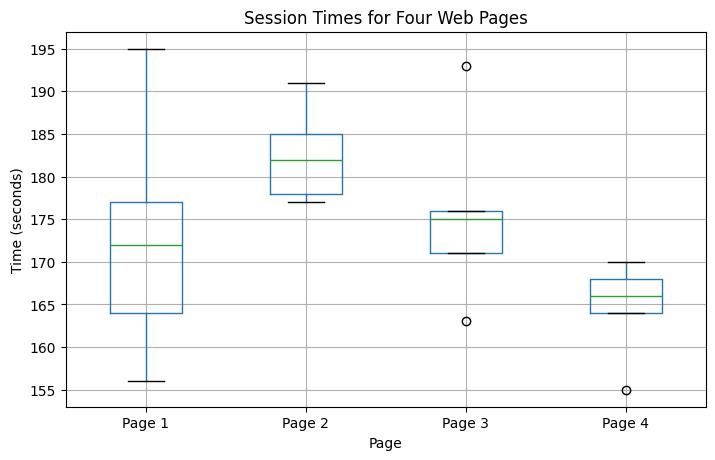

In [32]:
# Boxplot of session times for the four pages

ax = four_sessions.boxplot(
    by='Page',
    column='Time',
    figsize=(8, 5)
)

ax.set_xlabel('Page')
ax.set_ylabel('Time (seconds)')
ax.set_title('Session Times for Four Web Pages')

plt.suptitle('')
plt.show()

In [33]:
# Mean session time for each page

page_means = four_sessions.groupby('Page')['Time'].mean()

print(page_means)
print(f"\nGrand mean: {four_sessions['Time'].mean():.2f}")

Page
Page 1    172.8
Page 2    182.6
Page 3    175.6
Page 4    164.6
Name: Time, dtype: float64

Grand mean: 173.90


### Initial Observation

The four web pages have different average session times.

- Page 1: approximately 172.8 seconds
- Page 2: approximately 182.6 seconds
- Page 3: approximately 175.6 seconds
- Page 4: approximately 164.6 seconds

Page 2 has the highest observed average session time, while Page 4 has the lowest.

However, differences between sample means may occur because of random variation.

ANOVA is used to evaluate whether the overall differences among these four groups are greater than would reasonably be expected by chance.

### 3.8.1 Permutation Test for ANOVA

Under the null hypothesis, all four web pages are assumed to have the same underlying session-time distribution.

The observed session times can therefore be randomly reassigned among the four pages.

For each permutation:

1. The session-time values are randomly shuffled.
2. Five observations are assigned to each page.
3. The mean session time of each page is calculated.
4. The variance among the four page means is calculated.

Repeating this process produces a null distribution representing the amount of variation among group means that could occur by chance.

In [34]:
# Calculate observed variance among group means

observed_variance = (
    four_sessions
    .groupby('Page')['Time']
    .mean()
    .var()
)

print("Observed means:")
print(four_sessions.groupby('Page')['Time'].mean())

print(f"\nObserved variance: {observed_variance:.4f}")

Observed means:
Page
Page 1    172.8
Page 2    182.6
Page 3    175.6
Page 4    164.6
Name: Time, dtype: float64

Observed variance: 55.4267


In [36]:
# Permutation function for ANOVA

def perm_test_anova(df):
    df = df.copy()

    # Randomly shuffle session times
    df['Time'] = np.random.permutation(df['Time'].values)

    # Calculate variance among the shuffled group means
    return df.groupby('Page')['Time'].mean().var()

In [37]:
# Perform 3,000 permutations

np.random.seed(1)

perm_variance = [
    perm_test_anova(four_sessions)
    for _ in range(3000)
]

perm_variance = np.array(perm_variance)

print("Number of permutations:", len(perm_variance))

Number of permutations: 3000


In [38]:
# Calculate permutation p-value

p_value_anova_perm = np.mean(
    perm_variance > observed_variance
)

print(f"Permutation ANOVA p-value: {p_value_anova_perm:.4f}")

Permutation ANOVA p-value: 0.0727


### Interpretation of the Permutation ANOVA

The permutation test compares the observed variance among the four page means with the variance that could occur when session times are randomly reassigned.

The resulting p-value is greater than the conventional significance level of 0.05.

Therefore, the observed differences among the four web pages are not statistically significant at the 5% level.

The differences among the page means could reasonably have arisen from random variation.

### 3.8.2 F-Statistic

The **F-statistic** compares variation between group means with variation within the groups.

Conceptually:

F = Variance Between Groups / Variance Within Groups

or:

F = MS(treatment) / MS(error)

where **MS** represents mean square.

A larger F-statistic indicates that differences among group means are large relative to the variation within the groups.

The observed F-statistic can be compared with the theoretical **F-distribution** to calculate a p-value.

In [39]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [40]:
# Fit ANOVA model

model = smf.ols(
    'Time ~ C(Page)',
    data=four_sessions
).fit()

aov_table = sm.stats.anova_lm(model)

aov_table

,df,sum_sq,mean_sq,F,PR(>F)
C(Page),3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


### Interpretation of the ANOVA Table

The ANOVA results show:

- F-statistic ≈ 2.74
- p-value ≈ 0.0776

Using a significance level of:

α = 0.05

we have:

p-value > α

Therefore, the null hypothesis is not rejected.

There is insufficient statistical evidence to conclude that the mean session times differ significantly among the four web pages.

Although the sample means differ, the observed differences are still reasonably compatible with random variation.

### Understanding the ANOVA Table

The ANOVA table separates variability into different components.

**df (Degrees of Freedom)**  
The treatment has 3 degrees of freedom because there are four groups:

df = 4 - 1 = 3

The residual component has:

df = 20 - 4 = 16

**Sum of Squares (SS)**  
Measures the total squared variation associated with each source.

**Mean Square (MS)**  
Calculated by dividing Sum of Squares by its degrees of freedom:

MS = SS / df

**F-Statistic**  
Calculated as:

F = MS(treatment) / MS(error)

For this example:

F ≈ 277.13 / 101.15 ≈ 2.74

In [41]:
# Manually verify the F-statistic

ms_treatment = 831.4 / 3
ms_error = 1618.4 / 16

f_manual = ms_treatment / ms_error

print(f"MS Treatment: {ms_treatment:.4f}")
print(f"MS Error: {ms_error:.4f}")
print(f"F-statistic: {f_manual:.4f}")

MS Treatment: 277.1333
MS Error: 101.1500
F-statistic: 2.7398


### Key Takeaways

- ANOVA is used to compare the means of three or more groups.
- It provides an omnibus test instead of performing many separate pairwise tests.
- ANOVA compares between-group variation with within-group variation.
- A permutation ANOVA constructs a null distribution by repeatedly shuffling observations among groups.
- The F-statistic is calculated from the ratio of treatment mean square to residual mean square.
- In the four-page example, F ≈ 2.74 and p ≈ 0.0776.
- Since p > 0.05, the differences among the four page means are not statistically significant at the 5% level.

### 3.8.3 Two-Way ANOVA

A **one-way ANOVA** analyzes the effect of one factor on a numeric outcome.

A **two-way ANOVA** extends this approach by including two factors.

For example, a web experiment could involve:

- Factor 1: Web Page (A, B, C, D)
- Factor 2: Day Type (Weekday or Weekend)

This design makes it possible to investigate:

1. the effect of the web page,
2. the effect of the day type, and
3. the **interaction effect** between web page and day type.

An interaction effect occurs when the effect of one factor depends on the level of another factor.

Two-way ANOVA is therefore an extension of one-way ANOVA and provides a foundation for more general statistical models such as regression.

### Key Idea

ANOVA decomposes variability into components associated with:

- treatment effects,
- interaction effects, and
- residual error.

Two-way ANOVA extends the same basic ANOVA framework by incorporating an additional factor and its possible interaction with the first factor.

## 3.9 Chi-Square Test

### Theoretical Explanation

The **Chi-Square Test** is commonly used with count data to determine whether observed frequencies differ substantially from frequencies expected under a null hypothesis.

It is particularly useful for **contingency tables**, where observations are classified according to categorical variables.

### Important Terms

**Chi-Square Statistic**  
A measure of how far the observed counts differ from the expected counts.

**Observed Values**  
The actual frequencies recorded in the data.

**Expected Values**  
The frequencies that would be expected if the null hypothesis were true.

**Contingency Table**  
A table containing counts for combinations of categorical variables.

A small chi-square statistic indicates that the observed counts are relatively close to the expected counts.

A large chi-square statistic indicates a greater departure from what would be expected under the null hypothesis.

### 3.9.1 Web Headline Experiment

Three different web headlines are tested:

- Headline A
- Headline B
- Headline C

Each headline is shown to 1,000 visitors.

The observed results are:

| Outcome | Headline A | Headline B | Headline C |
|---|---:|---:|---:|
| Click | 14 | 8 | 12 |
| No-click | 986 | 992 | 988 |

Although Headline A appears to generate more clicks than Headline B, the number of clicks is relatively small.

The Chi-Square Test can be used to determine whether these differences are greater than what could reasonably occur because of random variation.

In [42]:
# Create the observed contingency table

clicks = pd.DataFrame({
    'Headline A': [14, 986],
    'Headline B': [8, 992],
    'Headline C': [12, 988]
}, index=['Click', 'No-click'])

clicks

,Headline A,Headline B,Headline C
Click,14,8,12
No-click,986,992,988


In [43]:
# Calculate expected counts under the null hypothesis

total_clicks = clicks.loc['Click'].sum()

expected_clicks = total_clicks / 3
expected_noclicks = 1000 - expected_clicks

print(f"Total clicks: {total_clicks}")
print(f"Expected clicks per headline: {expected_clicks:.2f}")
print(f"Expected no-clicks per headline: {expected_noclicks:.2f}")

Total clicks: 34
Expected clicks per headline: 11.33
Expected no-clicks per headline: 988.67


### Pearson Residuals and Chi-Square Statistic

The difference between observed and expected counts can be standardized using the **Pearson residual**:

R = (Observed - Expected) / √Expected

The chi-square statistic is then calculated by summing the squared Pearson residuals across all cells:

χ² = Σ R²

A larger chi-square statistic indicates a larger discrepancy between the observed data and what would be expected under the null hypothesis.

In [45]:
# Function to calculate chi-square statistic

def chi2_statistic(observed, expected):
    pearson_residuals = []

    for row, expect in zip(observed, expected):
        pearson_residuals.append(
            [(value - expect) ** 2 / expect for value in row]
        )

    return np.sum(pearson_residuals)


expected = [
    expected_clicks,
    expected_noclicks
]

chi2_observed = chi2_statistic(
    clicks.values,
    expected
)

print(f"Observed Chi-Square statistic: {chi2_observed:.4f}")

Observed Chi-Square statistic: 1.6659


### Chi-Square Test Using Resampling

Under the null hypothesis, all three headlines have the same click probability.

The resampling procedure is:

1. Create a pool containing 34 clicks (1) and 2,966 no-clicks (0).
2. Randomly distribute observations into three samples of 1,000 visitors.
3. Count the clicks in each sample.
4. Calculate the chi-square statistic.
5. Repeat the procedure many times.
6. Compare the resampled chi-square statistics with the observed chi-square statistic.

The proportion of resampled statistics greater than the observed statistic provides an estimate of the p-value.

In [46]:
# Create the pooled click/no-click data

box = [1] * 34
box.extend([0] * 2966)

print("Total observations:", len(box))
print("Total clicks:", sum(box))

Total observations: 3000
Total clicks: 34


In [47]:
def perm_chi_square(box):
    # Shuffle all 3,000 observations first
    shuffled = random.sample(box, len(box))

    # Divide into three independent groups of 1,000
    sample_A = shuffled[0:1000]
    sample_B = shuffled[1000:2000]
    sample_C = shuffled[2000:3000]

    sample_clicks = [
        sum(sample_A),
        sum(sample_B),
        sum(sample_C)
    ]

    sample_noclicks = [
        1000 - n for n in sample_clicks
    ]

    return chi2_statistic(
        [sample_clicks, sample_noclicks],
        expected
    )

In [48]:
# Perform 2,000 resampling iterations

random.seed(1)

perm_chi2 = [
    perm_chi_square(box)
    for _ in range(2000)
]

perm_chi2 = np.array(perm_chi2)

print("Number of simulations:", len(perm_chi2))

Number of simulations: 2000


In [49]:
# Calculate resampled p-value

resampled_p_value = np.mean(
    perm_chi2 > chi2_observed
)

print(f"Observed chi2: {chi2_observed:.4f}")
print(f"Resampled p-value: {resampled_p_value:.4f}")

Observed chi2: 1.6659
Resampled p-value: 0.4640


### Interpretation of the Resampling Chi-Square Test

The observed chi-square statistic is approximately **1.666**.

The resampling procedure produces a p-value of approximately **0.48**.

Since:

p-value > 0.05

the result is not statistically significant.

Therefore, the observed differences in click counts among Headlines A, B, and C can reasonably occur because of random variation.

There is insufficient evidence to conclude that the headlines have different underlying click rates.

### 3.9.6 Chi-Square Test Using the Chi-Square Distribution

Instead of estimating the null distribution through repeated resampling, the observed chi-square statistic can be compared with a theoretical **chi-square distribution**.

For an r × c contingency table, the degrees of freedom are:

df = (r - 1)(c - 1)

For the current 2 × 3 table:

df = (2 - 1)(3 - 1) = 2

The farther the observed chi-square statistic lies in the right tail of the reference distribution, the smaller the p-value.

In [52]:
from scipy import stats

In [53]:
# Chi-square test using scipy

chisq, pvalue, df, expected_table = stats.chi2_contingency(
    clicks
)

print(f"Observed chi2: {chisq:.4f}")
print(f"Degrees of freedom: {df}")
print(f"p-value: {pvalue:.4f}")

Observed chi2: 1.6659
Degrees of freedom: 2
p-value: 0.4348


In [54]:
expected_df = pd.DataFrame(
    expected_table,
    index=['Click', 'No-click'],
    columns=['Headline A', 'Headline B', 'Headline C']
)

expected_df

,Headline A,Headline B,Headline C
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


### Resampling vs Theoretical Chi-Square Test

The two approaches give similar conclusions:

| Method | Approximate p-value |
|---|---:|
| Resampling Chi-Square Test | ~0.48 |
| Theoretical Chi-Square Test | 0.4348 |

The values are not exactly identical because the theoretical chi-square distribution is an approximation to the actual distribution of the statistic.

However, both p-values are well above 0.05 and therefore lead to the same conclusion:

**The differences in click rates among the three headlines are not statistically significant.**

### Key Takeaways

- The Chi-Square Test is mainly used with count and categorical data.
- It compares observed frequencies with frequencies expected under the null hypothesis.
- The chi-square statistic measures the overall departure between observed and expected counts.
- A resampling approach can construct the null distribution directly from the observed data.
- A theoretical chi-square distribution provides an analytical approximation.
- Degrees of freedom for an r × c contingency table are calculated as (r - 1)(c - 1).
- In the headline experiment, χ² ≈ 1.666 with a theoretical p-value ≈ 0.4348.
- The result is not statistically significant at α = 0.05.

### 3.9.7 Fisher's Exact Test

The chi-square distribution provides a useful approximation for many contingency-table problems.

However, this approximation becomes less reliable when some observed counts are very small, particularly when counts are in the single digits.

In these situations, **Fisher's Exact Test** can provide a more accurate significance test.

Instead of relying on a theoretical chi-square approximation, Fisher's Exact Test considers the possible arrangements of the observed data and evaluates how extreme the observed arrangement is under the null hypothesis.

For the headline example in the book, Fisher's Exact Test produces a p-value close to the resampling result.

This supports the same conclusion that the differences among the headline click rates can reasonably be explained by random variation.

### 3.9.8 Relevance for Data Science

In traditional statistics, the Chi-Square Test and Fisher's Exact Test are often used to establish statistical significance.

In data science, however, the objective is often different.

Instead of asking only whether an effect is statistically significant, data scientists are often more interested in determining whether an effect, treatment, or feature is useful enough to deserve further attention.

Possible applications include:

- evaluating very low conversion-rate experiments,
- supporting power and sample-size calculations,
- filtering potentially useful variables or features,
- examining whether observed categorical patterns are compatible with random variation,
- and evaluating spatial or categorical distributions.

Therefore, chi-square-based methods can be used as screening or filtering tools rather than only as formal significance tests.

### Chi-Square Section Key Takeaways

- The Chi-Square Test is mainly used for count and categorical data.
- It compares observed counts with counts expected under the null hypothesis.
- Resampling provides a direct way to estimate the null distribution.
- The theoretical chi-square distribution provides an analytical approximation.
- Fisher's Exact Test is useful when counts are very small.
- In data science, chi-square methods can also be used for feature screening, experiment evaluation, and sample-size planning.

## 3.10 Multi-Arm Bandit Algorithm

### Theoretical Explanation

A **Multi-Arm Bandit** is an adaptive experimental strategy that can test multiple treatments while simultaneously attempting to maximize the reward obtained during the experiment.

The name comes from the analogy of a slot machine with multiple arms.

Each arm represents a different treatment.

### Important Terms

**Multi-Arm Bandit**  
A framework involving multiple possible treatments with different and initially unknown reward probabilities.

**Arm**  
A treatment or option in an experiment.

For example:

- Headline A
- Headline B
- Headline C

**Win**  
A successful outcome from a treatment.

For example:

- a click,
- a conversion,
- or another desired user response.

### Limitations of Traditional A/B Testing

Traditional A/B testing usually follows a fixed experimental design.

Visitors are randomly allocated to treatments until enough data have been collected.

After the experiment is completed, the results are analyzed and a decision is made.

This approach has several limitations:

- the result may remain inconclusive,
- an apparently inferior treatment may continue receiving many observations,
- information obtained during the experiment is not immediately used to change allocation,
- and additional treatments can make the decision process more complex.

Multi-arm bandit algorithms address these limitations by continuously learning from incoming results and adapting how frequently each treatment is selected.

### Example: Three Arms

Suppose three treatments are initially tested 50 times each:

| Arm | Wins | Trials | Observed Win Rate |
|---|---:|---:|---:|
| A | 10 | 50 | 20% |
| B | 2 | 50 | 4% |
| C | 4 | 50 | 8% |

Arm A appears to perform best.

A purely greedy strategy would immediately select Arm A for all future observations.

However, this creates a risk: Arm B or Arm C might actually be better, and their poor initial performance could simply be caused by random variation.

A multi-arm bandit takes a compromise approach.

It allocates more observations to the currently better-performing arm while still continuing to explore the other arms.

### Exploration vs Exploitation

A central problem in multi-arm bandits is the balance between:

**Exploitation**

Choosing the treatment that currently appears to perform best.

The goal is to maximize immediate reward.

**Exploration**

Continuing to test alternative treatments to obtain additional information.

The goal is to avoid prematurely selecting a treatment that only appears superior because of random variation.

An effective bandit algorithm balances these two objectives.

Too much exploitation may cause the algorithm to settle on the wrong treatment.

Too much exploration wastes observations on treatments that currently appear inferior.

### 3.10.4 Epsilon-Greedy Algorithm

The **epsilon-greedy algorithm** is one simple strategy for balancing exploration and exploitation.

For an A/B experiment:

1. Generate a random number between 0 and 1.
2. If the number is less than epsilon (ε), explore by randomly selecting one of the treatments.
3. Otherwise, exploit by selecting the treatment with the highest observed response rate.

The parameter **epsilon** controls how much exploration occurs.

If:

ε = 1

the algorithm always explores, which resembles a traditional randomized A/B experiment.

If:

ε = 0

the algorithm becomes completely greedy and always selects the treatment that currently appears best.

In [55]:
# Illustrative implementation of epsilon-greedy
# This code is added for practice; the book explains the algorithm conceptually.

import random

wins = {
    'A': 10,
    'B': 2,
    'C': 4
}

trials = {
    'A': 50,
    'B': 50,
    'C': 50
}

epsilon = 0.10

def epsilon_greedy_select(wins, trials, epsilon=0.10):

    # Exploration
    if random.random() < epsilon:
        return random.choice(list(wins.keys()))

    # Exploitation
    response_rates = {
        arm: wins[arm] / trials[arm]
        for arm in wins
    }

    return max(response_rates, key=response_rates.get)


selected_arm = epsilon_greedy_select(
    wins,
    trials,
    epsilon
)

print("Selected arm:", selected_arm)

Selected arm: A


In [56]:
for arm in wins:
    rate = wins[arm] / trials[arm]

    print(
        f"Arm {arm}: "
        f"{wins[arm]}/{trials[arm]} = "
        f"{rate:.2%}"
    )

Arm A: 10/50 = 20.00%
Arm B: 2/50 = 4.00%
Arm C: 4/50 = 8.00%


### Interpretation

Arm A currently has the highest observed response rate.

Therefore, during the exploitation phase, the epsilon-greedy algorithm will generally select Arm A.

However, with probability epsilon, the algorithm continues exploring the other arms.

This exploration prevents the experiment from permanently committing to an apparently superior treatment too early.

### 3.10.5 Thompson Sampling

**Thompson Sampling** is a more sophisticated multi-arm bandit algorithm based on Bayesian updating.

Initially, the reward probability of each arm is represented by a prior probability distribution.

For binary outcomes such as:

- click / no click,
- conversion / no conversion,

a beta distribution can be used to represent uncertainty about the success probability of each arm.

As additional outcomes are observed, the probability distributions are updated.

The algorithm repeatedly samples from these distributions and selects the arm that appears most likely to be the best.

As more information becomes available, the allocation increasingly favors treatments that show stronger performance.

### Why Multi-Arm Bandits Matter in Data Science

Multi-arm bandits are useful when an experiment has both a learning objective and an optimization objective.

Traditional A/B testing focuses mainly on learning which treatment performs better.

A multi-arm bandit also attempts to improve outcomes while the experiment is still running.

This approach is particularly useful for:

- website optimization,
- online advertisements,
- headlines,
- offers,
- recommendation systems,
- and other experiments where observations arrive continuously.

Multi-arm bandits can also handle more than two treatments efficiently.

### Key Takeaways

- A multi-arm bandit adaptively allocates observations among competing treatments.
- Each arm represents one experimental treatment.
- A win represents a successful outcome such as a click or conversion.
- Bandit algorithms balance **exploration** and **exploitation**.
- Exploitation favors the treatment that currently appears best.
- Exploration continues testing alternatives to avoid premature decisions.
- The epsilon-greedy algorithm controls exploration using the epsilon parameter.
- Thompson Sampling uses Bayesian updating to adapt treatment selection.
- Multi-arm bandits can be especially useful when testing three or more treatments.

## 3.11 Power and Sample Size

### Theoretical Explanation

**Power analysis** helps determine whether an experiment has enough observations to detect an effect of a specified size.

Three important concepts are:

**Effect Size**  
The minimum magnitude of an effect that the experiment should be able to detect.

For example, an experiment may be designed to detect a 10% improvement in click-through rate.

**Power**  
The probability that a statistical test will successfully detect a specified effect when that effect actually exists.

**Significance Level (Alpha)**  
The threshold used to determine statistical significance, commonly α = 0.05.

Larger effects are generally easier to detect and require smaller samples.

Smaller effects are more difficult to distinguish from random variation and therefore require larger samples.

### Components of Power Analysis

There are four closely related quantities in power and sample-size analysis:

1. **Sample Size**
2. **Effect Size**
3. **Significance Level (α)**
4. **Power**

If three of these quantities are specified, the fourth can be calculated.

In practice, sample size is often the quantity that needs to be determined.

Therefore, researchers typically specify:

- the minimum effect size worth detecting,
- the significance level,
- and the desired statistical power.

The required sample size is then calculated from these assumptions.

### 3.11.1 Sample Size Example

Suppose the current click-through rate is:

**1.10%**

The experiment is designed to detect a 10% relative improvement, producing a target click-through rate of:

**1.21%**

Thus:

- Existing treatment: p₂ = 0.011
- New treatment: p₁ = 0.0121

Assume:

- Significance level: α = 0.05
- Desired power: 0.80
- Alternative hypothesis: the new treatment performs better

The objective is to calculate how many observations are required in each treatment group.

In [57]:
import statsmodels.api as sm

In [58]:
# Calculate effect size

effect_size = sm.stats.proportion_effectsize(
    0.0121,
    0.011
)

print(f"Effect size: {effect_size:.6f}")

Effect size: 0.010298


In [59]:
# Calculate required sample size

analysis = sm.stats.TTestIndPower()

result = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.8,
    alternative='larger'
)

print('Sample Size: %.3f' % result)

Sample Size: 116602.391


### Interpretation

To detect an increase in click-through rate from 1.10% to 1.21% with:

- α = 0.05,
- power = 0.80,
- and a one-sided alternative,

approximately **116,602 observations are required per treatment group**.

This very large sample requirement occurs because the expected difference between the two click-through rates is small.

The example demonstrates an important principle:

**Small effects require larger samples to detect reliably.**

### Interpretation of Statistical Power

A statistical power of:

**0.80 or 80%**

means that, under the assumptions used in the power calculation, the statistical test has an 80% probability of detecting the specified effect when that effect actually exists.

Higher power generally requires a larger sample size.

Similarly:

- larger effect sizes require fewer observations,
- smaller effect sizes require more observations,
- stricter significance levels generally require more observations.

In [60]:
# Sample size for a larger 50% improvement
# CTR increases from 1.10% to 1.65%

effect_size_50 = sm.stats.proportion_effectsize(
    0.0165,
    0.011
)

result_50 = analysis.solve_power(
    effect_size=effect_size_50,
    alpha=0.05,
    power=0.8,
    alternative='larger'
)

print(f"Effect size for 50% improvement: {effect_size_50:.6f}")
print(f"Required sample size: {result_50:.0f} observations per group")

Effect size for 50% improvement: 0.047468
Required sample size: 5488 observations per group


### Comparing Effect Sizes

The effect size has a major influence on the required sample size.

For the same baseline click-through rate:

| Target Improvement | CTR Change | Approximate Required Sample |
|---|---|---:|
| 10% improvement | 1.10% → 1.21% | 116,602 per group |
| 50% improvement | 1.10% → 1.65% | about 5,500 per group |

A larger effect is easier to distinguish from random variation.

Therefore, considerably fewer observations are required to detect a large effect than a small effect.

### Intuitive Power Estimation Using Resampling

Power can also be understood through simulation.

A conceptual procedure is:

1. Create hypothetical data representing the current treatment.
2. Create a second population containing the desired effect.
3. Draw samples of size n from both populations.
4. Conduct a hypothesis test.
5. Record whether the result is statistically significant.
6. Repeat the procedure many times.

The proportion of repeated experiments that correctly detect the effect provides an estimate of statistical power.

This resampling perspective makes the meaning of power more intuitive: power represents how often an experiment of a given design would successfully detect the effect of interest.

### Key Takeaways

- Sample-size requirements depend on the effect that an experiment is designed to detect.
- **Effect size** represents the minimum meaningful difference of interest.
- **Power** represents the probability of detecting that effect when it exists.
- **Alpha** specifies the significance threshold of the hypothesis test.
- Sample size, effect size, alpha, and power are mathematically related.
- Smaller effects require larger samples.
- In the book example, detecting a CTR increase from 1.10% to 1.21% with 80% power requires approximately 116,602 observations per group.
- Increasing the target effect substantially reduces the required sample size.

# Chapter 3 Summary

## Statistical Experiments and Significance Testing

Chapter 3 introduced the statistical principles used to design experiments and evaluate whether observed differences are likely to represent meaningful effects or random variation.

The major concepts covered in this chapter include:

- **A/B Testing** for comparing experimental treatments using randomized treatment and control groups.
- **Hypothesis Testing**, including null and alternative hypotheses and one-sided versus two-sided tests.
- **Resampling and Permutation Tests** for constructing null distributions directly from observed data.
- **Statistical Significance and p-Values** for evaluating whether observed results are unusually extreme under a null model.
- **t-Tests** as analytical significance tests based on Student's t-distribution.
- **Multiple Testing** and the increased risk of false discoveries when many hypotheses are examined.
- **Degrees of Freedom**, which influence statistical reference distributions and the calculation of sample statistics.
- **ANOVA** for comparing the means of more than two groups.
- **Chi-Square Tests** for analyzing count and categorical data.
- **Fisher's Exact Test** for situations involving very small counts.
- **Multi-Arm Bandit Algorithms** for adaptive experimentation that balances exploration and exploitation.
- **Power and Sample Size Analysis** for determining how much data are required to detect effects of practical interest.

A central message of this chapter is that random variation can easily create apparent patterns or differences.

Traditional statistical inference provides formal methods such as p-values, t-tests, chi-square tests, and ANOVA to evaluate these differences.

For data science, resampling methods such as permutation tests provide an intuitive and flexible way to understand the role of chance.

Experimental design, randomization, appropriate control groups, and sufficient sample size remain essential for drawing reliable conclusions from data.